# Cumulative pre-match pollutant exposure (AUC) and t-tests
MLS Next Pro 2025 — 6-day exposure window: 5 training days + match day.

**Exposure window:** for each team and match, days 5 → 0 before kickoff (day 0 = match day).
- Home team: days 1–5 at its home/training region, day 0 at the stadium.
- Away team: days 3–5 at its home/training region, days 1–2 in the match (stadium) region (2 travel days), day 0 at the stadium.
- Days 1–5 come from `daily_exposure`; day 0 is pulled from `daily_environment` at the stadium location on the match date.

**AUC on discrete daily data.** With equally spaced daily observations (Δt = 1 day), the left Riemann sum is just the sum of the daily values, in units of *concentration × days*. The trapezoidal rule instead gives the two endpoint days (day 5 and match day) half weight. Both are computed below; the sum is the primary metric because each day is a full day of exposure (no reason to down-weight the endpoints). A recency-weighted variant (more weight on days closer to the match) is included as an optional sensitivity check.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats

RAW = Path("Raw Data")
WINDOW = 6   # 5 training days + match day
POLLUTANTS = ["pm25", "pm10", "no2", "o3", "us_aqi", "eu_aqi"]

exposure  = pd.read_csv(RAW / "daily_exposure.csv", parse_dates=["match_date", "exposure_date"])
environ   = pd.read_csv(RAW / "daily_environment.csv", parse_dates=["date"])
teams     = pd.read_csv("team_locations.csv")
stadiums  = pd.read_csv("stadiums.csv")
analysis  = pd.read_csv("analysis_dataset.csv", parse_dates=["match_date"])

print(exposure.shape, analysis.shape)
print(exposure.groupby(["home_away", "days_before"])["location_type"].first().unstack())

(4210, 37) (421, 194)
days_before             1             2            3            4            5
home_away                                                                     
away         match_region  match_region  home_region  home_region  home_region
home          home_region   home_region  home_region  home_region  home_region


## 1. Canonical team names + location check
`daily_exposure` mixes short aliases and full names (e.g. `Austin` vs `Austin FC II`, `Charlotte` vs `Crown Legacy FC`). Map everything to the canonical name in `team_locations.csv`, then confirm each exposure day sits at the right place: training location for home-region days, stadium for match-region days.

In [2]:
# The Town FC is San Jose's Next Pro affiliate; a few matches still use the old name
alias_map = {"San Jose Earthquakes II": "The Town FC", "SJ Earthquakes II": "The Town FC"}
for _, r in teams.iterrows():
    alias_map.setdefault(r["team"], r["team"])
    if isinstance(r["alias"], str):
        for a in r["alias"].split("|"):
            alias_map.setdefault(a.strip(), r["team"])

def canon(name):
    if name in alias_map:
        return alias_map[name]
    hits = [t for t in teams["team"] if name in t or t in name]
    return hits[0] if len(hits) == 1 else name

exposure["team_c"] = exposure["team"].map(canon)
exposure["opponent_c"] = exposure["opponent"].map(canon)
print("Unmapped names:", sorted(set(exposure["team_c"]) - set(teams["team"])) or "none")

# Location check: home-region days should match the team's training coordinates
loc = exposure.merge(teams[["team", "latitude", "longitude"]].rename(
    columns={"team": "team_c", "latitude": "train_lat", "longitude": "train_lon"}), on="team_c", how="left")
hr = loc[loc["location_type"] == "home_region"]
off = (hr["latitude"] - hr["train_lat"]).abs().gt(0.05) | (hr["longitude"] - hr["train_lon"]).abs().gt(0.05)
print(f"Home-region days not at training location: {off.sum()} / {len(hr)}")

# Match-region days should match the stadium of that match
st = analysis[["match_id", "stadium_id"]].merge(stadiums[["stadium_id", "latitude", "longitude"]], on="stadium_id", how="left")
mr = exposure[exposure["location_type"] == "match_region"].merge(st, on="match_id", suffixes=("", "_stad"))
off_m = (mr["latitude"] - mr["latitude_stad"]).abs().gt(0.05) | (mr["longitude"] - mr["longitude_stad"]).abs().gt(0.05)
print(f"Match-region days not at stadium: {off_m.sum()} / {len(mr)}")

missing = exposure[exposure["pm25"].isna()].groupby("team_c").size()
print("\nTeam-days with missing pollutant data (no coordinates):\n", missing)

Unmapped names: none
Home-region days not at training location: 0 / 3368
Match-region days not at stadium: 0 / 842

Team-days with missing pollutant data (no coordinates):
 team_c
C.D. Tapatío          3
Carolina Core FC    115
dtype: int64


## 2. Add match day (day 0)
`daily_exposure` only covers days 1–5. Both teams spend match day at the stadium, so day 0 is the stadium's daily mean on the match date from `daily_environment` (its `*_mean` columns are the same values as the `daily_exposure` pollutant columns).

In [3]:
stadium_key = (exposure[exposure["location_type"] == "match_region"]
               [["match_id", "match_date", "location_key", "latitude", "longitude"]]
               .drop_duplicates("match_id"))
env_day = (environ.rename(columns={f"{p}_mean": p for p in POLLUTANTS} | {"us_aqi_max": "us_aqi_dmax"})
           [["location_key", "date", "us_aqi_dmax"] + POLLUTANTS])  # daily max AQI kept for the alert threshold
match_day = stadium_key.merge(env_day, left_on=["location_key", "match_date"], right_on=["location_key", "date"], how="left")

teams_in_match = exposure[["match_id", "team", "team_c", "opponent", "opponent_c", "home_away"]].drop_duplicates()
day0 = teams_in_match.merge(match_day.drop(columns="date"), on="match_id")
day0 = day0.assign(exposure_date=day0["match_date"], days_before=0, location_type="match_day")

exposure = pd.concat([exposure, day0], ignore_index=True)
print("Match-day rows added:", len(day0), "| missing pm25 on match day:", day0["pm25"].isna().sum())
print(exposure.groupby(["home_away", "days_before"])["location_type"].first().unstack())

Match-day rows added: 842 | missing pm25 on match day: 0
days_before          0             1             2            3            4  \
home_away                                                                      
away         match_day  match_region  match_region  home_region  home_region   
home         match_day   home_region   home_region  home_region  home_region   

days_before            5  
home_away                 
away         home_region  
home         home_region  


## 3. Cumulative exposure (AUC) per team per match

In [4]:
def auc_sum(v):
    return v.sum() if v.notna().all() and len(v) == WINDOW else np.nan

def auc_trapz(v):
    return np.trapezoid(v.values) if v.notna().all() and len(v) == WINDOW else np.nan

# Optional: linear recency weights (match day = 6 ... day 5 before = 1), normalised to sum to WINDOW
def auc_recency(v, d):
    if not (v.notna().all() and len(v) == WINDOW):
        return np.nan
    w = (WINDOW - d.values).astype(float)
    return float((v.values * w).sum() * WINDOW / w.sum())

exposure = exposure.sort_values(["match_id", "team_c", "days_before"], ascending=[True, True, False])
rows = []
for (mid, team, ha), g in exposure.groupby(["match_id", "team_c", "home_away"]):
    rec = {"match_id": mid, "team": team, "home_away": ha, "match_date": g["match_date"].iloc[0]}
    for p in POLLUTANTS:
        rec[f"{p}_auc"] = auc_sum(g[p])
        rec[f"{p}_auc_trapz"] = auc_trapz(g[p])
        rec[f"{p}_auc_recency"] = auc_recency(g[p], g["days_before"])
    rows.append(rec)
auc = pd.DataFrame(rows)

# Team-level summary (mean cumulative exposure across the season)
team_auc = auc.groupby("team")[[f"{p}_auc" for p in POLLUTANTS]].agg(["mean", "count"]).round(1)
team_auc

pm25_auc       pm10_auc       no2_auc        \
                                  mean count     mean count    mean count   
team                                                                        
Atlanta United 2                  73.2    28     78.3    28    58.8    28   
Austin FC II                      57.8    27     71.9    27    45.9    27   
C.D. Tapatío                       NaN     0      NaN     0     NaN     0   
Carolina Core FC                   NaN     0      NaN     0     NaN     0   
Chattanooga FC                    63.8    29     67.9    29    47.8    29   
Chicago Fire FC II                74.7    30     77.6    30    93.5    30   
Colorado Rapids 2                 52.7    32     64.3    32    84.8    32   
Columbus Crew 2                   60.4    28     64.2    28    64.3    28   
Crown Legacy Football Club        70.5    28     75.0    28    51.9    28   
FC Cincinnati 2                   70.9    29     76.5    29    75.5    29   
Houston Dynamo 2                  76.6    28     96.2    28    80.1    28   
Huntsville City Football Club     62.1    30     66.2    30    35.3    30   
Inter Miami CF II                 56.5    28     79.2    28    49.8    28   
Los Angeles Football Club 2      109.3    28    126.9    28   192.5    28   
MNUFC2                            66.8    30     76.5    30    73.0    30   
NYCFC II                          80.7    28     85.5    28   142.9    28   
New England Revolution II         60.0    29     64.8    29    65.8    29   
New York Red Bulls II             74.7    32     78.9    32   129.7    32   
North Texas SC                    63.2    30     70.6    30    72.4    30   
Orlando City B                    52.3    28     62.8    28    49.1    28   
Philadelphia Union II             70.9    31     74.4    31    92.2    31   
Real Monarchs                     65.6    29    126.7    29    89.0    29   
Sporting KC II                    59.5    28     64.9    28    63.7    28   
St Louis CITY2                    59.8    30     66.5    30    67.1    30   
TFC II                            82.0    28     84.9    28   105.2    28   
Tacoma Defiance                   63.4    28     73.7    28    92.1    28   
The Town FC                       63.8    30     81.0    30    78.0    30   
Timbers2                          46.6    28     58.2    28    63.4    28   
Ventura County FC                 61.8    29     86.5    29    64.5    29   
Whitecaps FC 2                    83.9    29    103.4    29   135.4    29   

                              o3_auc       us_aqi_auc       eu_aqi_auc        
                                mean count       mean count       mean count  
team                                                                          
Atlanta United 2               537.4    28      380.5    28      273.0    28  
Austin FC II                   481.3    27      323.2    27      235.5    27  
C.D. Tapatío                     NaN     0        NaN     0        NaN     0  
Carolina Core FC                 NaN     0        NaN     0        NaN     0  
Chattanooga FC                 475.9    29      322.9    29      236.7    29  
Chicago Fire FC II             479.6    30      347.9    30      250.7    30  
Colorado Rapids 2              491.0    32      317.4    32      263.1    32  
Columbus Crew 2                492.4    28      325.8    28      245.8    28  
Crown Legacy Football Club     543.6    28      371.9    28      273.1    28  
FC Cincinnati 2                487.4    29      356.2    29      260.4    29  
Houston Dynamo 2               496.0    28      379.6    28      265.9    28  
Huntsville City Football Club  484.2    30      324.2    30      234.2    30  
Inter Miami CF II              446.6    28      303.5    28      216.3    28  
Los Angeles Football Club 2    351.5    28      403.7    28      286.7    28  
MNUFC2                         432.1    30      317.7    30      232.1    30  
NYCFC II                       429.4    28      361.8    28      2

## 4. Merge with outcomes
Wide format: one row per match with home/away AUC and AUC difference (home − away, matching `exposure_orientation` in `analysis_dataset`).

In [5]:
h = auc[auc.home_away == "home"].drop(columns="home_away").add_prefix("home_").rename(columns={"home_match_id": "match_id"})
a = auc[auc.home_away == "away"].drop(columns="home_away").add_prefix("away_").rename(columns={"away_match_id": "match_id"})
wide = h.merge(a, on="match_id").merge(analysis[["match_id", "home_goals", "away_goals", "home_xg", "away_xg"]], on="match_id")

for p in POLLUTANTS:
    wide[f"{p}_auc_diff"] = wide[f"home_{p}_auc"] - wide[f"away_{p}_auc"]
wide["goal_diff"] = wide["home_goals"] - wide["away_goals"]
wide["result"] = np.select([wide.goal_diff > 0, wide.goal_diff < 0], ["home_win", "away_win"], "draw")
print(wide.shape); print(wide["result"].value_counts())

(421, 53)
result
home_win    184
away_win    141
draw         96
Name: count, dtype: int64


## 5. T-tests on cumulative exposure

**(a) Paired t-test — home vs away AUC.** Do the two teams in a match enter with different cumulative exposure? (Paired within match, since both teams share game-day conditions.)

**(b) Paired t-test — winner vs loser AUC.** Draws excluded. Tests whether the losing side carried more pre-match pollution exposure.

**(c) Welch t-test — high vs low exposure.** Splits team-matches at the median AUC and compares goals scored. Unpaired, unequal variances.

In [6]:
def paired(x, y):
    m = x.notna() & y.notna()
    t, p = stats.ttest_rel(x[m], y[m])
    d = (x[m] - y[m])
    return dict(n=int(m.sum()), mean_1=x[m].mean(), mean_2=y[m].mean(), mean_diff=d.mean(),
                cohens_dz=d.mean() / d.std(ddof=1), t=t, p=p)

# (a) home vs away
res_a = pd.DataFrame({p: paired(wide[f"home_{p}_auc"], wide[f"away_{p}_auc"]) for p in POLLUTANTS}).T
res_a = res_a.rename(columns={"mean_1": "home_mean", "mean_2": "away_mean"})
print("(a) Paired t-test: home vs away 6-day AUC")
display(res_a.round(3))

# (b) winner vs loser
dec = wide[wide.result != "draw"]
hw = dec.result == "home_win"
res_b = {}
for p in POLLUTANTS:
    win  = np.where(hw, dec[f"home_{p}_auc"], dec[f"away_{p}_auc"])
    lose = np.where(hw, dec[f"away_{p}_auc"], dec[f"home_{p}_auc"])
    res_b[p] = paired(pd.Series(win), pd.Series(lose))
res_b = pd.DataFrame(res_b).T.rename(columns={"mean_1": "winner_mean", "mean_2": "loser_mean"})
print("(b) Paired t-test: winner vs loser 6-day AUC (draws excluded)")
display(res_b.round(3))

(a) Paired t-test: home vs away 6-day AUC


,n,home_mean,away_mean,mean_diff,cohens_dz,t,p
pm25,391.0,67.771,66.708,1.063,0.047,0.924,0.356
pm10,391.0,79.058,78.316,0.742,0.029,0.573,0.567
no2,391.0,81.866,81.234,0.633,0.016,0.318,0.751
o3,391.0,458.177,458.732,-0.556,-0.008,-0.155,0.877
us_aqi,391.0,337.845,335.564,2.281,0.037,0.739,0.461
eu_aqi,391.0,247.719,247.392,0.327,0.008,0.167,0.867


(b) Paired t-test: winner vs loser 6-day AUC (draws excluded)


,n,winner_mean,loser_mean,mean_diff,cohens_dz,t,p
pm25,307.0,67.843,67.001,0.842,0.035,0.619,0.536
pm10,307.0,80.285,78.682,1.603,0.060,1.047,0.296
no2,307.0,85.216,82.522,2.694,0.064,1.126,0.261
o3,307.0,455.727,452.001,3.726,0.052,0.914,0.362
us_aqi,307.0,336.668,333.265,3.403,0.055,0.958,0.339
eu_aqi,307.0,248.761,245.177,3.585,0.091,1.600,0.111


In [7]:
# (c) Team-match level: goals scored, high vs low cumulative exposure
long = auc.merge(analysis[["match_id", "home_goals", "away_goals"]], on="match_id")
long["goals_for"] = np.where(long.home_away == "home", long.home_goals, long.away_goals)

res_c = {}
for p in POLLUTANTS:
    s = long[[f"{p}_auc", "goals_for"]].dropna()
    hi = s[f"{p}_auc"] > s[f"{p}_auc"].median()
    t, pv = stats.ttest_ind(s.loc[hi, "goals_for"], s.loc[~hi, "goals_for"], equal_var=False)
    res_c[p] = dict(n_high=int(hi.sum()), n_low=int((~hi).sum()),
                    goals_high=s.loc[hi, "goals_for"].mean(), goals_low=s.loc[~hi, "goals_for"].mean(), t=t, p=pv)
res_c = pd.DataFrame(res_c).T
print("(c) Welch t-test: goals scored, above vs below median AUC")
display(res_c.round(3))

(c) Welch t-test: goals scored, above vs below median AUC


,n_high,n_low,goals_high,goals_low,t,p
pm25,406.0,406.0,1.771,1.663,1.142,0.254
pm10,406.0,406.0,1.739,1.695,0.467,0.641
no2,406.0,406.0,1.791,1.643,1.559,0.119
o3,406.0,406.0,1.645,1.788,-1.506,0.132
us_aqi,406.0,406.0,1.732,1.702,0.311,0.756
eu_aqi,406.0,406.0,1.798,1.635,1.715,0.087


## 6. Sensitivity: trapezoidal and recency-weighted AUC
Re-runs test (b) with the alternative AUC definitions. If the conclusions match, the summation choice doesn't matter.

In [8]:
sens = []
for suffix in ["auc", "auc_trapz", "auc_recency"]:
    for p in POLLUTANTS:
        hcol = h.set_index("match_id").loc[dec.match_id, f"home_{p}_{suffix}"].values
        acol = a.set_index("match_id").loc[dec.match_id, f"away_{p}_{suffix}"].values
        win, lose = np.where(hw, hcol, acol), np.where(hw, acol, hcol)
        r = paired(pd.Series(win), pd.Series(lose))
        sens.append(dict(method=suffix, pollutant=p, mean_diff=r["mean_diff"], t=r["t"], p=r["p"]))
pd.DataFrame(sens).pivot(index="pollutant", columns="method", values=["mean_diff", "p"]).round(3)

mean_diff                            p                      
method          auc auc_recency auc_trapz    auc auc_recency auc_trapz
pollutant                                                             
eu_aqi        3.585       2.412     3.357  0.111       0.086     0.079
no2           2.694       2.062     2.374  0.261       0.225     0.254
o3            3.726       1.894     3.257  0.362       0.491     0.359
pm10          1.603       0.991     1.563  0.296       0.298     0.225
pm25          0.842       0.687     0.902  0.536       0.428     0.433
us_aqi        3.403       2.542     3.500  0.339       0.244     0.246

## 7. Difference-in-differences with an AQI alert-day treatment

**Treatment intensity = number of alert days (daily US AQI > 100) in the 5 training days before a match, 0–5.**
- AQI 100 is the EPA line for "Unhealthy for Sensitive Groups", where air quality alerts are issued.
- CIF athletics guidance: at AQI ≥ 100, pull at-risk athletes; above 150, consider rescheduling or moving indoors and avoid prolonged exertion.
- Daily AQI = daily max of Open-Meteo's hourly US AQI, which already applies EPA averaging periods (24-h PM, 8-h O₃).

Three designs, each in its own section below. **Design A (rolling window) is the lead specification**; B and C are supporting.

| | **A — Rolling window (lead)** | **B — Weekly dose** | **C — Season-cumulative (staggered)** |
|---|---|---|---|
| Treatment | ≥ `ROLL_K` alert days in the trailing `ROLL_W` days before the match; **resets** when the air clears | alert days in the 5 training days (0–5) | absorbing: treated from the first match where season-to-date alert days reach `K_CUM` |
| Where the team was | actual location each day: training base, the match city on away travel days, stadium on match day | same | training base only |
| Matches the acute mechanism? | yes, recent sustained exposure | yes, but only 5 days | no; stays "treated" after the air clears |
| Model | `y ~ treated + home + controls \| team + week` plus a stacked switch-on event study | `y ~ alert_days + ... \| team + week` | event study + `did2s` |

Both use team fixed effects and calendar-week fixed effects, with SEs clustered by team.

In [9]:
# pip install pyfixest
import pyfixest as pf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message=".*singleton fixed effect.*")

ALERT_AQI = 100
OUTCOMES = ["goals", "xg", "goal_diff", "pass_acc", "shots", "shots_on_target", "fouls"]

# Alert days in the 5 training days (days_before 1-5; match day excluded)
training = exposure[exposure.days_before.between(1, 5)]
win = (training.groupby(["match_id", "team_c", "home_away"])
       .agg(match_date=("match_date", "first"),
            days_with_data=("us_aqi_dmax", "count"),
            alert_days=("us_aqi_dmax", lambda s: int((s > ALERT_AQI).sum())))
       .reset_index().rename(columns={"team_c": "team"}))
win = win[win.days_with_data == 5]

opp = (win[["match_id", "home_away", "alert_days"]]
       .assign(home_away=lambda d: d.home_away.map({"home": "away", "away": "home"}))
       .rename(columns={"alert_days": "opp_alert"}))
win = win.merge(opp, on=["match_id", "home_away"], how="left")

perf = []
for side, o in [("home", "away"), ("away", "home")]:
    perf.append(pd.DataFrame({
        "match_id": analysis.match_id, "home_away": side,
        "goals": analysis[f"{side}_goals"], "xg": analysis[f"{side}_xg"],
        "goal_diff": analysis[f"{side}_goals"] - analysis[f"{o}_goals"],
        "pass_acc": analysis[f"{side}_passing_accuracy"],
        "shots": analysis[f"{side}_shots"], "shots_on_target": analysis[f"{side}_shots_on_target"],
        "fouls": analysis[f"{side}_fouls"]}))
panel = (win.merge(pd.concat(perf), on=["match_id", "home_away"])
         .sort_values(["team", "match_date"]).reset_index(drop=True))
panel["home"] = (panel.home_away == "home").astype(int)
panel["week"] = panel.match_date.dt.strftime("%G-%V")      # calendar-week fixed effect
panel["match_no"] = panel.groupby("team").cumcount() + 1   # position in the team's season

print("Matches per team:", panel.groupby("team").size().describe()[["min", "50%", "max"]].to_dict())
print("Alert days in training window:"); print(panel.alert_days.value_counts().sort_index().to_string())

Matches per team: {'min': 27.0, '50%': 29.0, 'max': 32.0}
Alert days in training window:
alert_days
0    503
1    107
2     89
3     63
4     29
5     21


### Controls: weather and altitude
Available in the data (`precip_sum` and `wind_*` are empty in `daily_environment`, so precipitation and wind can't be included):

| Control | Definition | Why |
|---|---|---|
| `train_temp`, `train_temp_sq` | mean daily temperature over the 5 training days (and its square) | heat drives ozone formation and affects training load; squared term allows a non-linear effect |
| `train_hum` | mean daily humidity over the 5 training days | heat stress; also affects particle concentrations |
| `md_temp`, `md_temp_sq`, `md_hum` | temperature and humidity at the stadium on match day | game-day conditions (shared by both teams, but differ week to week) |
| `elev_stadium` | stadium elevation (m) | altitude reduces aerobic capacity |

Heat index, wet bulb and dew point are functions of temperature + humidity, so they are left out to avoid collinearity. Elevation *gain* (stadium − training base) is not included separately: the team's base elevation never changes, so once team fixed effects are in, gain is perfectly collinear with stadium elevation. The `elev_stadium` coefficient therefore already measures the effect of playing higher than usual.

In [10]:
# Training-window weather (days 1-5 at wherever the team was)
train_wx = (training.groupby(["match_id", "team_c", "home_away"])
      .agg(train_temp=("temperature", "mean"), train_hum=("humidity", "mean"))
      .reset_index().rename(columns={"team_c": "team"}))

# Match-day weather at the stadium
md_wx = (stadium_key[["match_id", "match_date", "location_key"]]
         .merge(environ[["location_key", "date", "temperature_mean", "humidity_mean"]],
                left_on=["location_key", "match_date"], right_on=["location_key", "date"], how="left")
         [["match_id", "temperature_mean", "humidity_mean"]]
         .rename(columns={"temperature_mean": "md_temp", "humidity_mean": "md_hum"}))

# Altitude: stadium elevation and gain relative to the team's training base
elev = (analysis[["match_id", "stadium_id"]]
        .merge(stadiums[["stadium_id", "elevation"]], on="stadium_id", how="left")
        .rename(columns={"elevation": "elev_stadium"})[["match_id", "elev_stadium"]])

panel = (panel.merge(train_wx, on=["match_id", "team", "home_away"], how="left")
              .merge(md_wx, on="match_id", how="left")
              .merge(elev, on="match_id", how="left")
              .merge(teams[["team", "elevation"]].rename(columns={"elevation": "elev_base"}), on="team", how="left"))
panel["elev_gain"] = panel.elev_stadium - panel.elev_base
panel["train_temp_sq"] = panel.train_temp ** 2
panel["md_temp_sq"] = panel.md_temp ** 2
panel[["elev_stadium", "elev_gain"]] = panel[["elev_stadium", "elev_gain"]] / 100   # per 100 m

CONTROLS = "train_temp + train_temp_sq + train_hum + md_temp + md_temp_sq + md_hum + elev_stadium"
ctrl_cols = CONTROLS.split(" + ")
print("Rows with all controls:", panel[ctrl_cols].notna().all(axis=1).sum(), "/", len(panel))
panel[ctrl_cols].describe().T[["mean", "std", "min", "max"]].round(2)

Rows with all controls: 788 / 812


,mean,std,min,max
train_temp,19.86,6.12,2.01,31.42
train_temp_sq,431.89,223.95,4.03,987.06
train_hum,69.28,10.02,35.79,91.11
md_temp,20.18,6.13,1.64,31.73
md_temp_sq,444.88,228.06,2.70,1007.00
md_hum,69.22,13.19,19.42,97.62
elev_stadium,2.38,3.77,0.00,16.09


---
## 7A. DESIGN A — Rolling window, resets (LEAD)

**Unit:** team × match day. **Treatment:** a team's match day is treated if the team had at least `ROLL_K` alert days (daily AQI > 100) in the `ROLL_W`-day window *ending on match day* (the `ROLL_W − 1` days before plus match day itself). Treatment turns **off** again once the trailing window clears, so it can switch on and off over a season.

**Exposure series:** every calendar day at the team's training base (`daily_environment`), replaced by the actual location wherever `daily_exposure` says the team was elsewhere: the match city on away travel days, and the stadium on match day.

**Main specification, fixed before looking at the sweep:** `ROLL_W = 14` (roughly the two-week training cycle between matches) and `ROLL_K = 7` (bad air on at least half of those days, "a bad fortnight"). The full grid of windows and thresholds is shown afterwards so the choice is transparent.

**Estimators:**
1. **TWFE** with team + calendar-week fixed effects and weather/altitude controls, SEs clustered by team.
2. **Stacked switch-on event study:** events are matches where the team was untreated at the previous match. Treated events switch on (untreated → treated); control events stay untreated. Time runs over matches −2…+2, with the reference at −1. This is the same structure as `monthly.R` (`i(time_to_treat, treated, ref = -1)`).

In [11]:
ROLL_W, ROLL_K = 14, 7

# Daily AQI series per team at its ACTUAL location
team_key = (exposure[exposure.location_type == "home_region"].dropna(subset=["location_key"])
            .drop_duplicates("team_c")[["team_c", "location_key"]].rename(columns={"team_c": "team"}))
base = (team_key.merge(environ[["location_key", "date", "us_aqi_max"]], on="location_key")
        [["team", "date", "us_aqi_max"]].rename(columns={"us_aqi_max": "aqi"}))
away_days = (exposure[exposure.location_type != "home_region"].drop(columns="team")   # match-city travel days + match day
             .rename(columns={"team_c": "team", "exposure_date": "date", "us_aqi_dmax": "aqi"})
             .dropna(subset=["aqi"]).groupby(["team", "date"], as_index=False).aqi.max())
series = pd.concat([base[~base.set_index(["team", "date"]).index.isin(away_days.set_index(["team", "date"]).index)],
                    away_days], ignore_index=True).sort_values(["team", "date"])
print("Team-days replaced by match-city / stadium AQI:", len(away_days))
series["alert"] = (series.aqi > ALERT_AQI).astype(int)

def add_rolling(df, W):
    s_ = series.copy()
    s_[f"roll{W}"] = s_.groupby("team").alert.transform(lambda x: x.rolling(W, min_periods=W).sum())
    s_["match_date"] = s_.date                                         # window ends ON match day (W-1 days before + match day)
    return df.drop(columns=[f"roll{W}"], errors="ignore").merge(s_[["team", "match_date", f"roll{W}"]],
                                                                on=["team", "match_date"], how="left")

panel = add_rolling(panel, ROLL_W)
panel["treated_r"] = np.where(panel[f"roll{ROLL_W}"].isna(), np.nan, (panel[f"roll{ROLL_W}"] >= ROLL_K).astype(float))
print(f"Treated team-match-days (>= {ROLL_K} alert days in the {ROLL_W}-day window ending on match day):",
      int(panel.treated_r.sum()), "/", int(panel.treated_r.notna().sum()))
switches = panel.groupby("team").treated_r.apply(lambda x: int((x.diff().abs() == 1).sum()))
print("Treatment switches per team (on or off):", switches.describe()[["min", "50%", "max"]].to_dict())

Team-days replaced by match-city / stadium AQI: 1684
Treated team-match-days (>= 7 alert days in the 14-day window ending on match day): 108 / 788
Treatment switches per team (on or off): {'min': 0.0, '50%': 2.0, 'max': 8.0}


In [12]:
SPECS_R = {"base": "home", "+controls": f"home + {CONTROLS}"}
rows = []
for y in OUTCOMES:
    for spec, rhs in SPECS_R.items():
        r = pf.feols(f"{y} ~ treated_r + {rhs} | team + week", data=panel, vcov={"CRV1": "team"}).tidy().loc["treated_r"]
        rows.append({"outcome": y, "spec": spec, "ATT": r["Estimate"], "p": r["Pr(>|t|)"], "lo": r["2.5%"], "hi": r["97.5%"]})
design_r = pd.DataFrame(rows)
design_r["sig"] = np.select([design_r.p < .01, design_r.p < .05, design_r.p < .1], ["***", "**", "*"], "")
design_r["cell"] = (design_r.ATT.round(3).astype(str) + design_r.sig + " [" + design_r.lo.round(2).astype(str)
                    + ", " + design_r.hi.round(2).astype(str) + "]")
print(f"DESIGN A — TWFE: >= {ROLL_K} alert days in last {ROLL_W} vs fewer (team + week FE; 95% CI)")
design_r.pivot(index="outcome", columns="spec", values="cell")[["base", "+controls"]]

DESIGN A — TWFE: >= 7 alert days in last 14 vs fewer (team + week FE; 95% CI)


spec,base,+controls
outcome,,
fouls,"-0.765 [-1.74, 0.21]","-0.631 [-1.66, 0.4]"
goal_diff,"0.038 [-0.61, 0.68]","0.041 [-0.64, 0.72]"
goals,"0.055 [-0.39, 0.5]","0.151 [-0.31, 0.61]"
pass_acc,"-0.122 [-0.94, 0.69]","-0.223 [-1.15, 0.71]"
shots,"0.412 [-0.66, 1.48]","0.377 [-0.67, 1.42]"
shots_on_target,"0.363 [-0.34, 1.07]","0.419 [-0.31, 1.15]"
xg,"-0.009 [-0.28, 0.26]","-0.017 [-0.3, 0.26]"


### 7A in percentage terms: log outcomes
Coefficients are converted to **% change = 100 × (exp(β) − 1)**.
- **xG, passing accuracy, shots, fouls:** OLS on `log(y)`. None of these is ever zero.
- **Goals, shots on target:** Poisson pseudo-maximum likelihood (PPML, `fepois`). Goals are 0 in about 20% of team-match-days, so `log(goals)` would drop every scoreless match and bias the estimate. PPML keeps the zeros, and its coefficient reads as a % change in the same way.
- **Goal difference** can be negative, so it has no log and is left out.

In [13]:
LOG_OLS = ["xg", "pass_acc", "shots", "fouls"]     # strictly positive -> log(y)
PPML    = ["goals", "shots_on_target"]             # counts with zeros -> Poisson
PCT_OUTCOMES = LOG_OLS + PPML
for y in LOG_OLS:
    panel[f"log_{y}"] = np.log(panel[y])

def pct_effect(y, treat, rhs, data, fe="team + week"):
    """% change in y when `treat` switches 0 -> 1 (or per unit), with 95% CI."""
    if y in PPML:
        m = pf.fepois(f"{y} ~ {treat} + {rhs} | {fe}", data=data, vcov={"CRV1": "team"})
    else:
        m = pf.feols(f"log_{y} ~ {treat} + {rhs} | {fe}", data=data, vcov={"CRV1": "team"})
    r = m.tidy().loc[treat]
    pct = lambda b: 100 * (np.exp(b) - 1)
    return {"pct": pct(r["Estimate"]), "lo": pct(r["2.5%"]), "hi": pct(r["97.5%"]), "p": r["Pr(>|t|)"],
            "model": "PPML" if y in PPML else "log-OLS"}

rows = []
for y in PCT_OUTCOMES:
    for spec, rhs in SPECS_R.items():
        rows.append({"outcome": y, "spec": spec, **pct_effect(y, "treated_r", rhs, panel)})
design_r_pct = pd.DataFrame(rows)
design_r_pct["sig"] = np.select([design_r_pct.p < .01, design_r_pct.p < .05, design_r_pct.p < .1], ["***", "**", "*"], "")
design_r_pct["cell"] = (design_r_pct.pct.round(1).astype(str) + "%" + design_r_pct.sig + " [" +
                        design_r_pct.lo.round(1).astype(str) + ", " + design_r_pct.hi.round(1).astype(str) + "]")
print(f"DESIGN A — % change on treated match days (>= {ROLL_K} alert days in {ROLL_W}-day window); 95% CI")
out = design_r_pct.pivot(index="outcome", columns="spec", values="cell")[["base", "+controls"]]
out.insert(0, "model", design_r_pct.drop_duplicates("outcome").set_index("outcome").model)
out.loc[PCT_OUTCOMES]

DESIGN A — % change on treated match days (>= 7 alert days in 14-day window); 95% CI


spec,model,base,+controls
outcome,,,
xg,log-OLS,"-1.3% [-15.8, 15.7]","-0.5% [-14.6, 15.8]"
pass_acc,log-OLS,"-0.2% [-1.2, 0.9]","-0.3% [-1.4, 0.9]"
shots,log-OLS,"-0.2% [-9.3, 9.8]","-0.2% [-9.1, 9.7]"
fouls,log-OLS,"-6.7%* [-13.1, 0.2]","-5.8% [-12.4, 1.3]"
goals,PPML,"1.9% [-19.2, 28.5]","7.2% [-15.7, 36.3]"
shots_on_target,PPML,"6.8% [-5.3, 20.5]","8.1% [-5.0, 22.9]"


Switch-on events: 37 | stay-untreated controls: 616


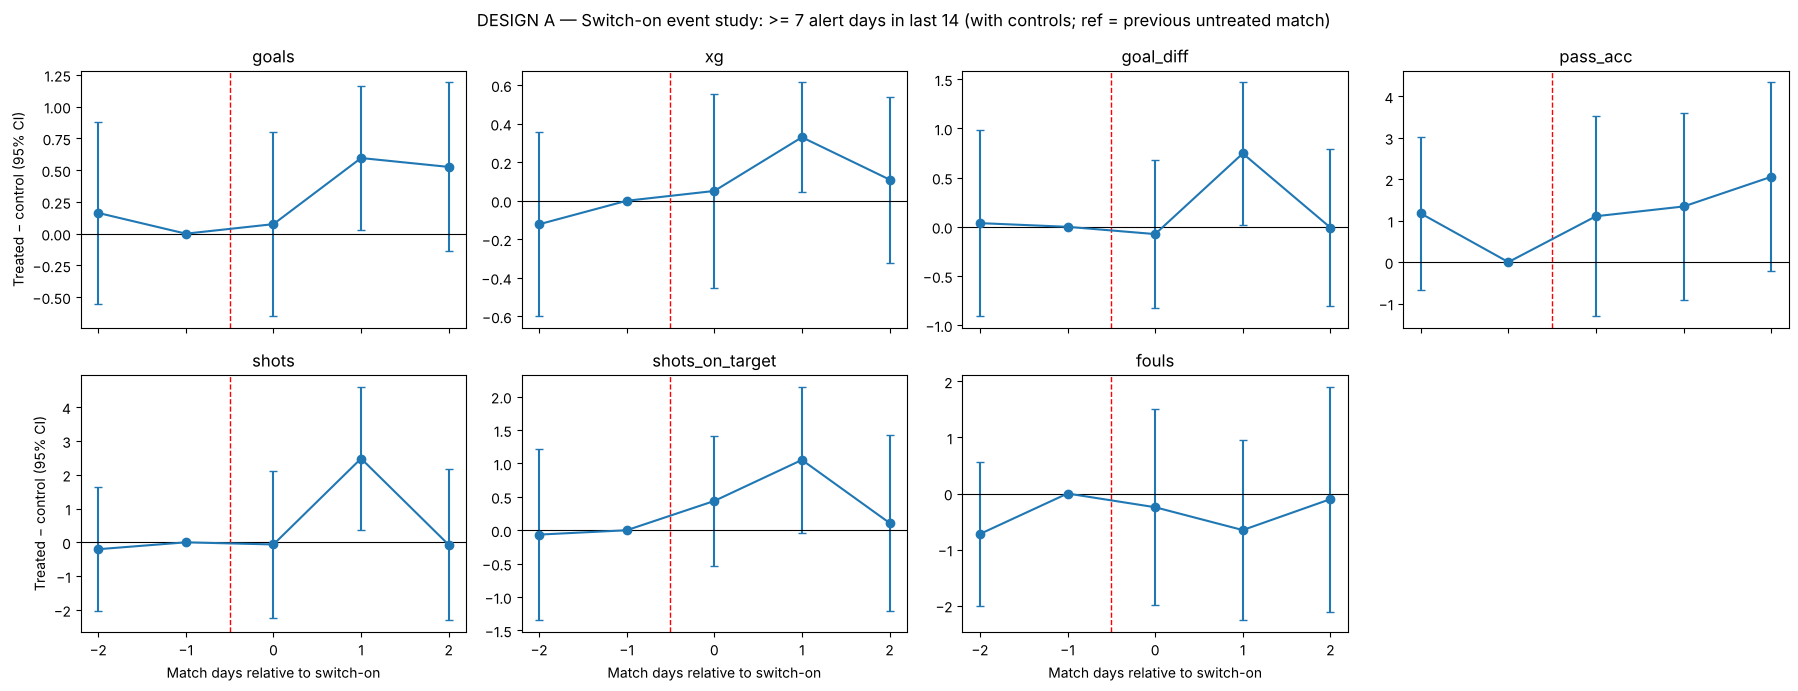

In [14]:
def stack_switch_on(treat_col, window=(-2, 2)):
    out = []
    for team, g in panel.dropna(subset=[treat_col]).groupby("team"):
        g = g.reset_index(drop=True)
        for i in range(1, len(g)):
            if g.loc[i - 1, treat_col] != 0:
                continue
            for r in range(window[0], window[1] + 1):
                if 0 <= i + r < len(g):
                    row = g.loc[i + r, OUTCOMES + ["home"] + ctrl_cols].to_dict()
                    row.update(event=f"{team}_{i}", team=team, rel=r, treated=int(g.loc[i, treat_col]))
                    out.append(row)
    return pd.DataFrame(out)

ev_r = stack_switch_on("treated_r")
e0 = ev_r.query("rel == 0")
print(f"Switch-on events: {int(e0.treated.sum())} | stay-untreated controls: {int((e0.treated == 0).sum())}")

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, y in zip(axes.flat, OUTCOMES):
    m = pf.feols(f"{y} ~ i(rel, treated, ref=-1) + home + {CONTROLS} | event + rel", data=ev_r, vcov={"CRV1": "team"})
    tb = m.tidy().filter(like="rel::", axis=0)
    k = tb.index.str.extract(r"::(-?\d+)")[0].astype(int).values
    est = pd.DataFrame({"k": k, "b": tb["Estimate"].values, "lo": tb["2.5%"].values, "hi": tb["97.5%"].values})
    est = pd.concat([est, pd.DataFrame({"k": [-1], "b": [0.0], "lo": [0.0], "hi": [0.0]})]).sort_values("k")
    ax.errorbar(est.k, est.b, yerr=[est.b - est.lo, est.hi - est.b], fmt="o-", capsize=3)
    ax.axhline(0, c="k", lw=.8); ax.axvline(-0.5, c="r", ls="--", lw=1)
    ax.set_title(y); ax.set_xticks(range(-2, 3))
axes.flat[-1].axis("off")
for ax in axes[1]: ax.set_xlabel("Match days relative to switch-on")
for ax in axes[:, 0]: ax.set_ylabel("Treated − control (95% CI)")
fig.suptitle(f"DESIGN A — Switch-on event study: >= {ROLL_K} alert days in last {ROLL_W} (with controls; ref = previous untreated match)")
plt.tight_layout(); plt.show()

### 7A sensitivity: window length × threshold
Reruns the % change model (log-OLS / PPML, with controls) for every window `W` ∈ {7, 14, 21, 28} and threshold `K`, keeping thresholds where 5–95% of team-match-days are treated. The x-axis is **K / W**, the share of days in the window with bad air, so windows of different lengths line up. Red dots are p < 0.05.

**Multiple testing:** this grid runs several hundred regressions, so about 5% will hit p < 0.05 by chance alone. Read it for *consistent patterns across windows*, not for individual significant points. Inference should rest on the main specification above.

252 regressions; 18 with p < 0.05 (~13 expected by chance)


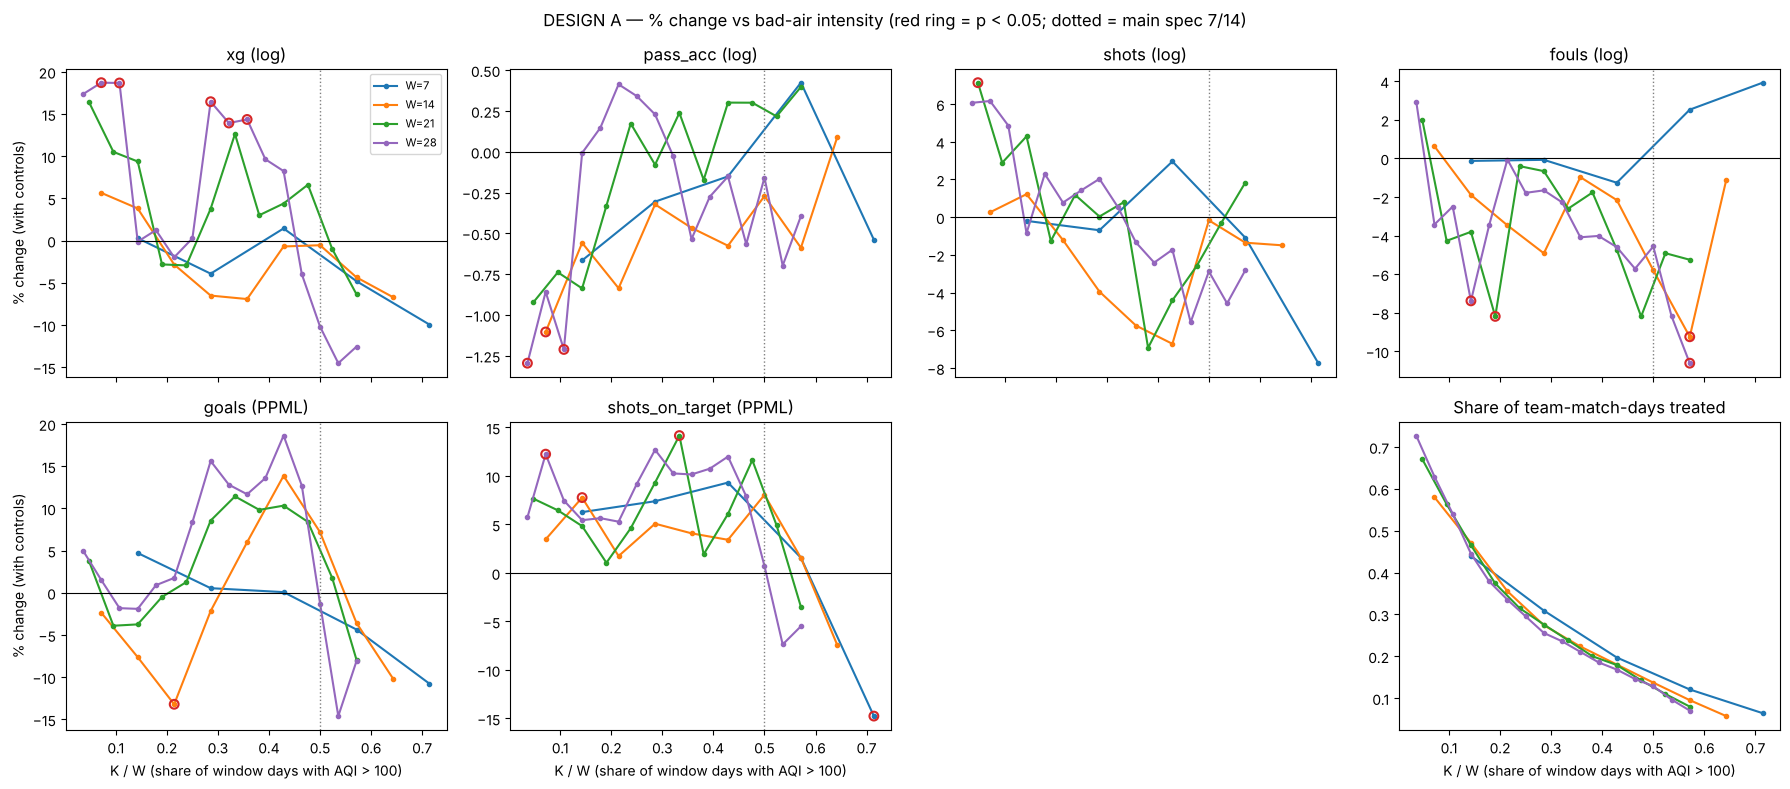

In [15]:
WINDOWS = [7, 14, 21, 28]
grid = []
tmp = panel.copy()
for W in WINDOWS:
    tmp = add_rolling(tmp, W)
    for K in range(1, W + 1):
        tr = (tmp[f"roll{W}"] >= K).astype(float).where(tmp[f"roll{W}"].notna())
        share = tr.mean()
        if not (0.05 <= share <= 0.95):
            continue
        d = tmp.assign(tr=tr)
        for y in PCT_OUTCOMES:
            r = pct_effect(y, "tr", SPECS_R["+controls"], d)
            grid.append({"W": W, "K": K, "frac": K / W, "share_treated": share, "outcome": y, **r})
grid = pd.DataFrame(grid)
print(f"{len(grid)} regressions; {int((grid.p < .05).sum())} with p < 0.05 "
      f"(~{0.05 * len(grid):.0f} expected by chance)")

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
colors = dict(zip(WINDOWS, ["tab:blue", "tab:orange", "tab:green", "tab:purple"]))
for ax, y in zip(axes.flat, PCT_OUTCOMES):
    for W in WINDOWS:
        g = grid[(grid.outcome == y) & (grid.W == W)]
        ax.plot(g.frac, g.pct, "o-", ms=3, c=colors[W], label=f"W={W}")
        sig = g[g.p < .05]
        ax.scatter(sig.frac, sig.pct, s=40, facecolors="none", edgecolors="tab:red", lw=1.5, zorder=3)
    ax.axhline(0, c="k", lw=.8); ax.axvline(ROLL_K / ROLL_W, c="gray", ls=":", lw=1)
    ax.set_title(f"{y} ({'PPML' if y in PPML else 'log'})")
axes.flat[0].legend(fontsize=8)
axes.flat[-2].axis("off")
sh = grid.drop_duplicates(["W", "K"])
ax = axes.flat[-1]
for W in WINDOWS:
    g = sh[sh.W == W]; ax.plot(g.frac, g.share_treated, "o-", ms=3, c=colors[W])
ax.set_title("Share of team-match-days treated")
for ax in axes[1]: ax.set_xlabel("K / W (share of window days with AQI > 100)")
for ax in axes[:, 0]: ax.set_ylabel("% change (with controls)")
fig.suptitle(f"DESIGN A — % change vs bad-air intensity (red ring = p < 0.05; dotted = main spec {ROLL_K}/{ROLL_W})")
plt.tight_layout(); plt.show()

In [16]:
panel["dose"] = panel.alert_days.clip(upper=3)   # 0, 1, 2, 3+ (4-5 day weeks are rare)
SPECS = {"base": "opp_alert + home", "+controls": f"opp_alert + home + {CONTROLS}"}

rows = []
for y in OUTCOMES:
    for spec, rhs in SPECS.items():
        r = pf.feols(f"{y} ~ alert_days + {rhs} | team + week", data=panel, vcov={"CRV1": "team"}).tidy().loc["alert_days"]
        row = {"outcome": y, "spec": spec, "per_alert_day": r["Estimate"], "p": r["Pr(>|t|)"]}
        tb = pf.feols(f"{y} ~ i(dose, ref=0) + {rhs} | team + week", data=panel, vcov={"CRV1": "team"}).tidy()
        for lvl, lab in [(1, "1 day"), (2, "2 days"), (3, "3+ days")]:
            k = [ix for ix in tb.index if ix.startswith("dose::") and ix.endswith(f"::{lvl}")][0]
            row[lab] = tb.loc[k, "Estimate"]; row[f"p {lab}"] = tb.loc[k, "Pr(>|t|)"]
        rows.append(row)
design_a = pd.DataFrame(rows).set_index(["outcome", "spec"])
print("DESIGN B — effect vs. a week with 0 alert days (team + week FE, clustered by team)")
print("base = opponent alert days + home | +controls adds weather and altitude")
design_a.round(3)

DESIGN B — effect vs. a week with 0 alert days (team + week FE, clustered by team)
base = opponent alert days + home | +controls adds weather and altitude


per_alert_day      p  1 day  p 1 day  2 days  \
outcome         spec                                                      
goals           base               0.020  0.672  0.015    0.918   0.296   
                +controls          0.046  0.321  0.003    0.984   0.340   
xg              base               0.009  0.776  0.097    0.445   0.082   
                +controls         -0.000  0.992  0.095    0.463   0.066   
goal_diff       base               0.033  0.654  0.038    0.869   0.331   
                +controls          0.037  0.632  0.005    0.984   0.370   
pass_acc        base               0.234  0.076 -1.287    0.035   0.007   
                +controls          0.153  0.328 -1.566    0.011  -0.391   
shots           base               0.116  0.487 -0.074    0.904  -0.409   
                +controls          0.110  0.524 -0.069    0.912  -0.522   
shots_on_target base               0.077  0.383  0.107    0.709   0.386   
                +controls          0.070  0.401  0.114    0.695   0.277   
fouls           base               0.108  0.492  0.458    0.307   0.274   
                +controls          0.130  0.412  0.248    0.573   0.167   

                           p 2 days  3+ days  p 3+ days  
outcome         spec                                     
goals           base          0.153    0.022      0.895  
                +controls     0.125    0.113      0.507  
xg              base          0.500    0.036      0.744  
                +controls     0.633    0.003      0.980  
goal_diff       base          0.329    0.126      0.643  
                +controls     0.282    0.133      0.659  
pass_acc        base          0.990    0.909      0.070  
                +controls     0.507    0.628      0.257  
shots           base          0.537    0.807      0.175  
                +controls     0.480    0.792      0.191  
shots_on_target base          0.260    0.376      0.250  
                +controls     0.448    0.397      0.196  
fouls           base          0.565    0.334      0.611  
                +controls     0.707    0.407      0.552

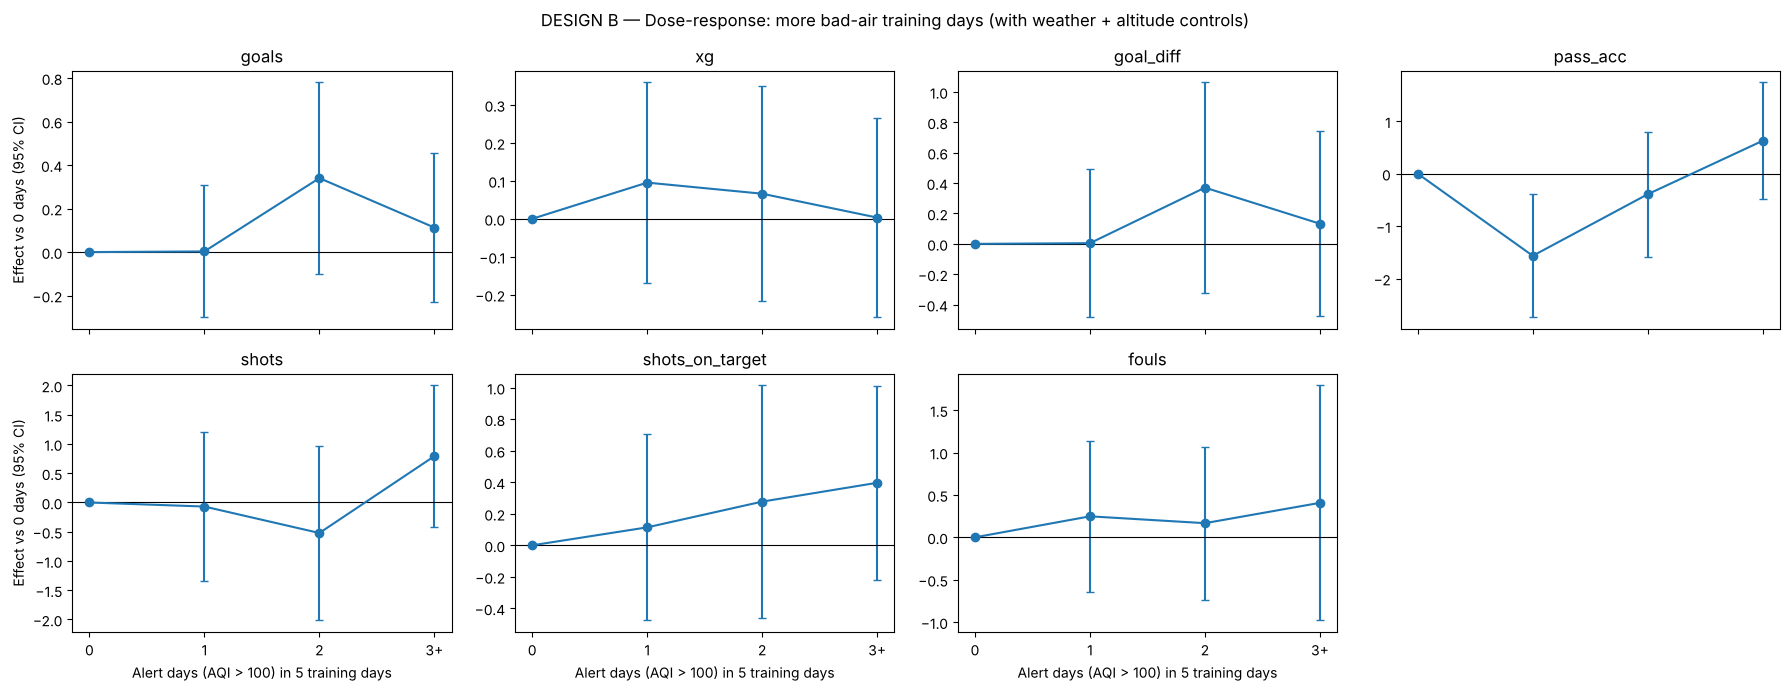

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, y in zip(axes.flat, OUTCOMES):
    tb = pf.feols(f"{y} ~ i(dose, ref=0) + {SPECS['+controls']} | team + week", data=panel, vcov={"CRV1": "team"}).tidy()
    tb = tb[tb.index.str.startswith("dose::")]
    lv = [0] + [int(ix.split("::")[-1]) for ix in tb.index]
    b, lo, hi = [0] + list(tb["Estimate"]), [0] + list(tb["2.5%"]), [0] + list(tb["97.5%"])
    ax.errorbar(lv, b, yerr=[np.subtract(b, lo), np.subtract(hi, b)], fmt="o-", capsize=3)
    ax.axhline(0, c="k", lw=.8); ax.set_title(y)
    ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(["0", "1", "2", "3+"])
axes.flat[-1].axis("off")
for ax in axes[1]: ax.set_xlabel("Alert days (AQI > 100) in 5 training days")
for ax in axes[:, 0]: ax.set_ylabel("Effect vs 0 days (95% CI)")
fig.suptitle("DESIGN B — Dose-response: more bad-air training days (with weather + altitude controls)")
plt.tight_layout(); plt.show()

---
## 7C. DESIGN C — Season-cumulative, staggered adoption (each team's season is one line)

- **Season-to-date alert days:** counted over *every* calendar day at the team's training location (from `daily_environment`), from the start of the data through the day before each match. This isn't limited to the 5-day windows.
- **Treatment:** a team is treated from the first match where that count reaches `K_CUM`, and stays treated (absorbing). Teams cross at different points in the season (staggered).
- **Never-treated teams:** teams that never reach `K_CUM` serve as controls throughout.
- **time_to_treat:** match number minus the crossing match, binned at ±6. This is the analog of `time_to_treat` in `monthly.R`.
- **Two estimators:**
  - **TWFE event study:** same as `feols(... i(time_to_treat, treated, ref = -1))` in R.
  - **Gardner's two-stage DiD (`did2s`):** robust to the bias plain TWFE has when treatment timing is staggered and effects vary.
- **Choosing `K_CUM`:** 15 days gives a mix of crossing times (mostly June–August) and leaves 9 never-treated teams. Change it in the cell below.

K_CUM = 15: 19 treated teams, 9 never treated
Crossing month: {'July': 9, 'August': 4, 'June': 4, 'September': 1, 'May': 1}


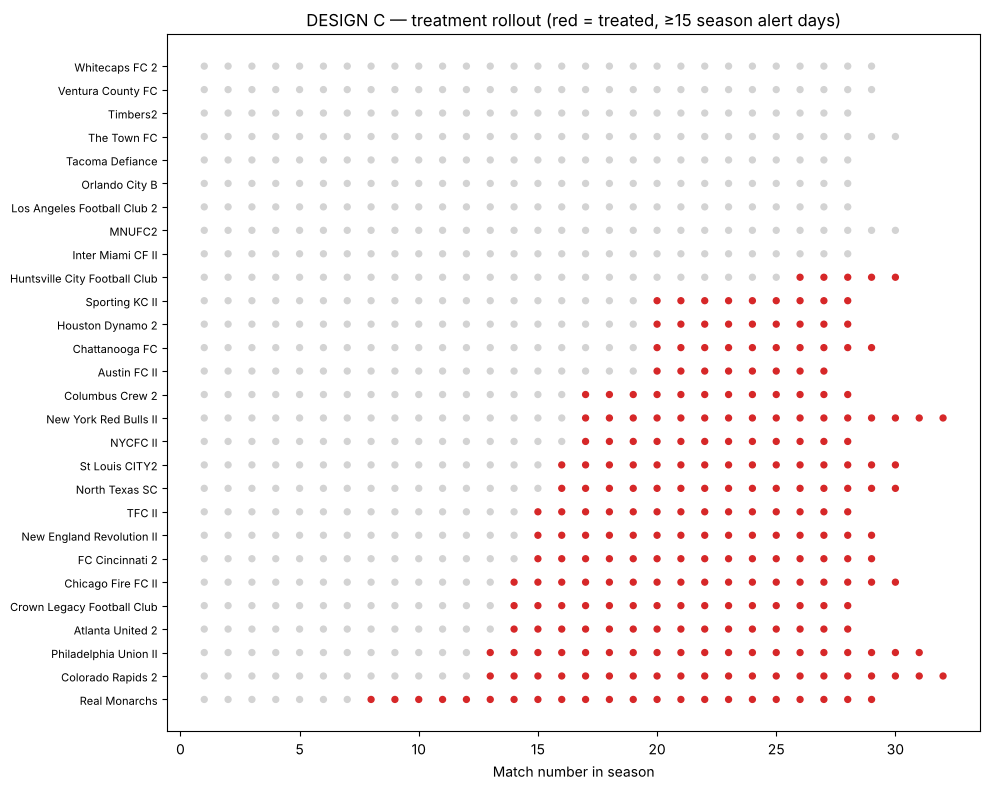

In [18]:
K_CUM = 15        # season-to-date alert days that switch treatment on

# Daily AQI at each team's training location, every calendar day
team_key = (exposure[exposure.location_type == "home_region"].dropna(subset=["location_key"])
            .drop_duplicates("team_c")[["team_c", "location_key"]].rename(columns={"team_c": "team"}))
daily = (team_key.merge(environ[["location_key", "date", "us_aqi_max"]], on="location_key")
         .sort_values(["team", "date"]))
daily["alert"] = (daily.us_aqi_max > ALERT_AQI).astype(int)
daily["cum_alert"] = daily.groupby("team").alert.cumsum()
daily["match_date"] = daily.date + pd.Timedelta(days=1)            # count through the day before the match

panel = panel.drop(columns=[c for c in ["cum_alert"] if c in panel]).merge(
    daily[["team", "match_date", "cum_alert"]], on=["team", "match_date"], how="left")

first = panel[panel.cum_alert >= K_CUM].groupby("team").match_no.min()
panel["first_treated"] = panel.team.map(first)
panel["treated_b"] = (panel.match_no >= panel.first_treated).astype(int)
panel["ever_treated"] = panel.first_treated.notna().astype(int)
panel["time_to_treat"] = np.where(panel.ever_treated == 1,
                                  (panel.match_no - panel.first_treated).clip(-6, 6), -99).astype(int)
panel["ttt_twfe"] = panel.time_to_treat.replace(-99, -1)           # never-treated sit in the reference bin

cross = panel.drop_duplicates("team").set_index("team")
cross_dates = panel[panel.match_no == panel.first_treated].set_index("team").match_date
print(f"K_CUM = {K_CUM}: {int(cross.ever_treated.sum())} treated teams, "
      f"{int((1 - cross.ever_treated).sum())} never treated")
print("Crossing month:", cross_dates.dt.month_name().value_counts().to_dict())

# Each team's season as a line: when does treatment switch on?
fig, ax = plt.subplots(figsize=(10, 8))
order = panel.groupby("team").first_treated.first().fillna(99).sort_values().index
for yi, tm in enumerate(order):
    g = panel[panel.team == tm]
    ax.scatter(g.match_no, [yi] * len(g), c=np.where(g.treated_b == 1, "tab:red", "lightgray"), s=18)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel("Match number in season"); ax.set_title(f"DESIGN C — treatment rollout (red = treated, ≥{K_CUM} season alert days)")
plt.tight_layout(); plt.show()

In [19]:
SPECS_B = {"base": "home", "+controls": f"home + {CONTROLS}"}
rows = []
for y in OUTCOMES:
    for spec, rhs in SPECS_B.items():
        r = pf.feols(f"{y} ~ treated_b + {rhs} | team + week", data=panel, vcov={"CRV1": "team"}).tidy().loc["treated_b"]
        rows.append({"outcome": y, "spec": spec, "ATT": r["Estimate"], "se": r["Std. Error"], "p": r["Pr(>|t|)"]})
design_b = pd.DataFrame(rows)
design_b["sig"] = np.select([design_b.p < .01, design_b.p < .05, design_b.p < .1], ["***", "**", "*"], "")
design_b["cell"] = design_b.ATT.round(3).astype(str) + design_b.sig + " (p=" + design_b.p.round(3).astype(str) + ")"
print(f"DESIGN C — static TWFE DiD: after vs before crossing {K_CUM} season alert days")
design_b.pivot(index="outcome", columns="spec", values="cell")[["base", "+controls"]]

DESIGN C — static TWFE DiD: after vs before crossing 15 season alert days


spec,base,+controls
outcome,,
fouls,-0.773 (p=0.199),-0.614 (p=0.289)
goal_diff,0.369* (p=0.087),0.374 (p=0.111)
goals,0.32** (p=0.015),0.356*** (p=0.009)
pass_acc,0.914 (p=0.171),0.888 (p=0.196)
shots,0.608 (p=0.36),0.341 (p=0.651)
shots_on_target,1.045*** (p=0.0),1.02*** (p=0.001)
xg,0.227* (p=0.051),0.169 (p=0.123)


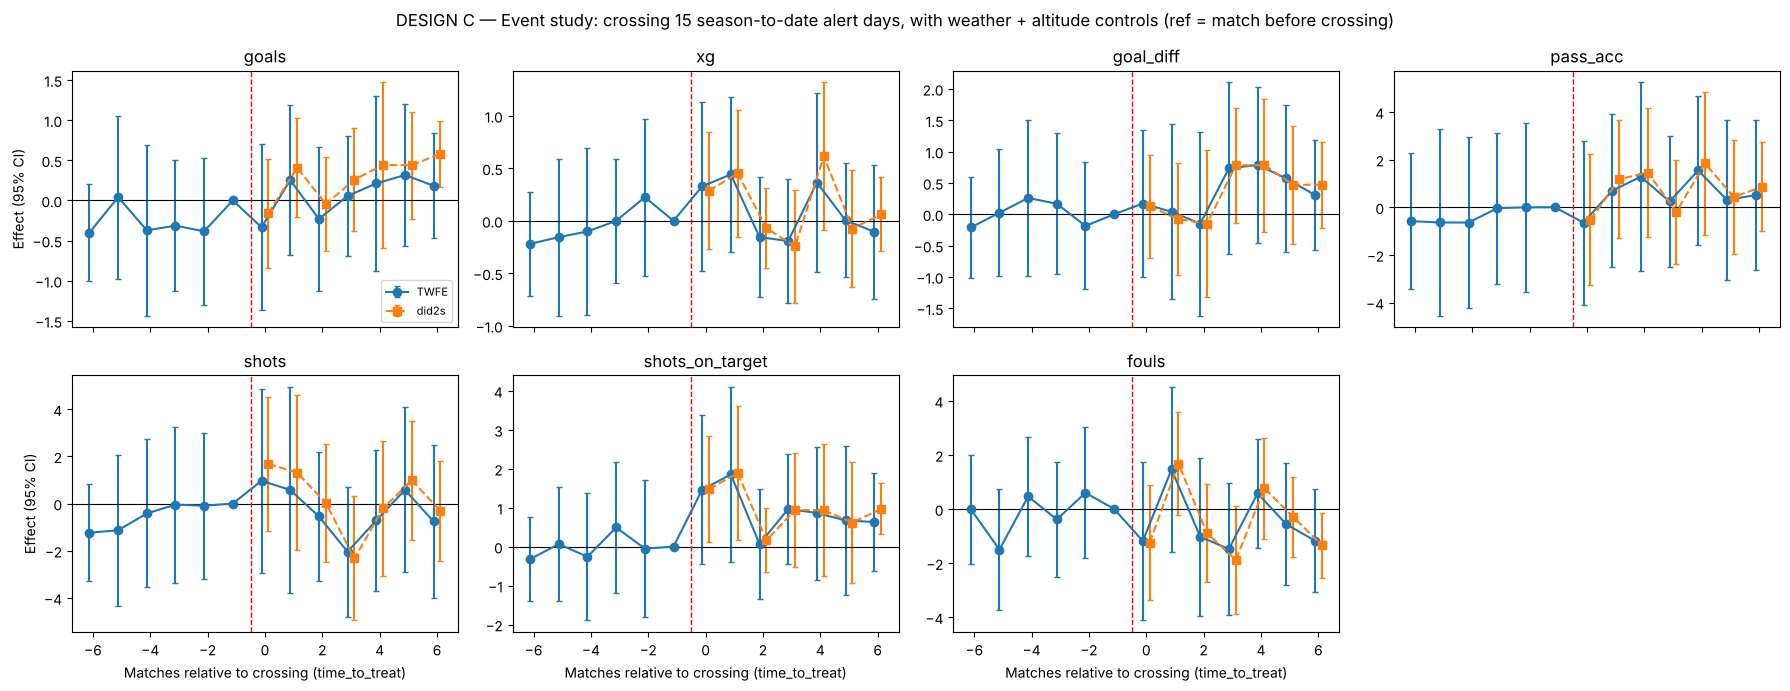

In [20]:
def es_coefs(tb, prefix):
    tb = tb[tb.index.str.contains(prefix)]
    k = tb.index.str.extract(r"::(-?\d+)")[0].astype(int).values
    out = pd.DataFrame({"k": k, "b": tb["Estimate"].values, "lo": tb["2.5%"].values, "hi": tb["97.5%"].values})
    return pd.concat([out, pd.DataFrame({"k": [-1], "b": [0.0], "lo": [0.0], "hi": [0.0]})]).query("k > -99").sort_values("k")

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for ax, y in zip(axes.flat, OUTCOMES):
    tw = pf.feols(f"{y} ~ i(ttt_twfe, ref=-1) + {SPECS_B['+controls']} | team + week", data=panel, vcov={"CRV1": "team"}).tidy()
    e1 = es_coefs(tw, "ttt_twfe")
    ax.errorbar(e1.k - 0.12, e1.b, yerr=[e1.b - e1.lo, e1.hi - e1.b], fmt="o-", capsize=2, label="TWFE")
    try:
        dd = panel.dropna(subset=[y] + ctrl_cols)
        # first stage needs >= 2 untreated obs in every week/team (drops the Cup-final week and singletons)
        for _ in range(5):
            u = dd[dd.treated_b == 0]
            wk, tm = u.week.value_counts(), u.team.value_counts()
            dd = dd[dd.week.isin(wk[wk >= 2].index) & dd.team.isin(tm[tm >= 2].index)]
        d2 = pf.did2s(dd, yname=y, first_stage=f"~ {SPECS_B['+controls']} | team + week",
                      second_stage="~ i(time_to_treat, ref=-99)", treatment="treated_b", cluster="team").tidy()
        e2 = es_coefs(d2, "time_to_treat").query("k >= 0")   # did2s identifies post-period effects
        ax.errorbar(e2.k + 0.12, e2.b, yerr=[e2.b - e2.lo, e2.hi - e2.b], fmt="s--", capsize=2, label="did2s")
    except Exception as ex:
        print(f"did2s failed for {y}: {ex}")
    ax.axhline(0, c="k", lw=.8); ax.axvline(-0.5, c="r", ls="--", lw=1); ax.set_title(y)
axes.flat[0].legend(fontsize=8)
axes.flat[-1].axis("off")
for ax in axes[1]: ax.set_xlabel("Matches relative to crossing (time_to_treat)")
for ax in axes[:, 0]: ax.set_ylabel("Effect (95% CI)")
fig.suptitle(f"DESIGN C — Event study: crossing {K_CUM} season-to-date alert days, with weather + altitude controls (ref = match before crossing)")
plt.tight_layout(); plt.show()

### 7C sensitivity: how the DiD coefficient moves with the threshold `K_CUM`
Reruns the static TWFE DiD for every threshold from 1 to the largest value that still leaves at least `MIN_GROUP` treated *and* `MIN_GROUP` never-treated teams. The top panels show the ATT with a 95% CI band for each outcome. The bottom-right panel shows how many teams are treated at each threshold, because composition changes as `K` rises: only the most polluted teams stay treated, and the never-treated pool grows.

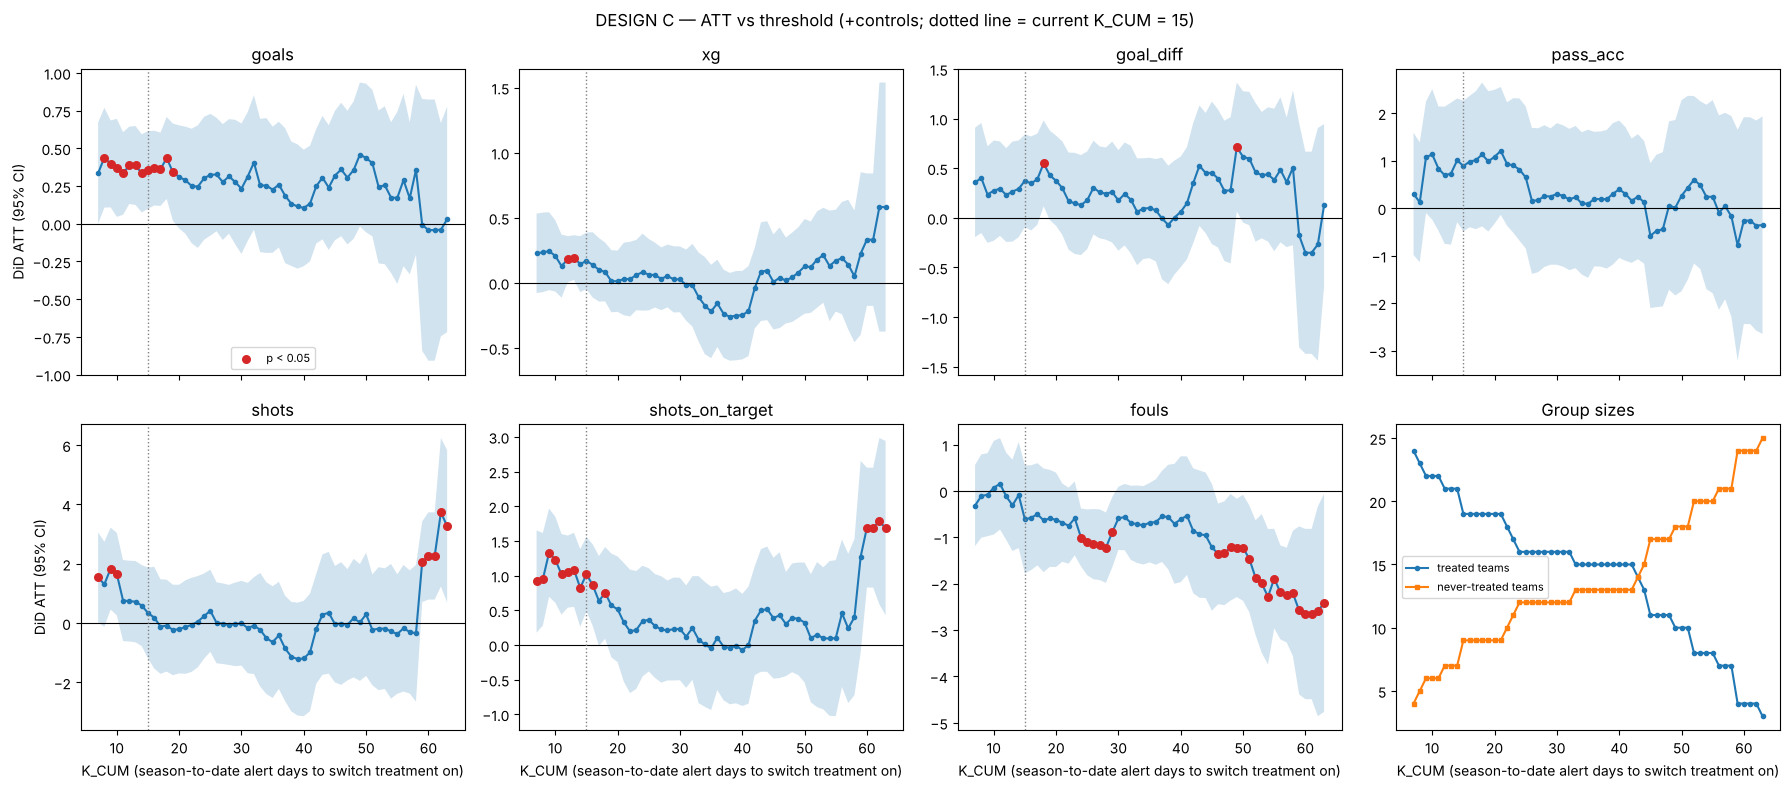

outcome,n_treated,fouls,goal_diff,goals,pass_acc,shots,shots_on_target,xg
K,,,,,,,,
7,24,-0.313,0.356,0.335,0.303,1.541,0.914,0.226
8,23,-0.109,0.401,0.438,0.125,1.307,0.946,0.234
9,22,-0.079,0.234,0.396,1.072,1.836,1.329,0.244
10,22,0.072,0.274,0.370,1.133,1.653,1.229,0.207
11,22,0.156,0.293,0.333,0.834,0.760,1.017,0.129
12,21,-0.115,0.229,0.387,0.693,0.742,1.057,0.181
13,21,-0.308,0.264,0.386,0.728,0.722,1.083,0.194
14,21,-0.087,0.292,0.334,1.009,0.591,0.823,0.144
15,19,-0.614,0.374,0.356,0.888,0.341,1.020,0.169


In [21]:
SPEC_SWEEP = "+controls"       # or "base"
MIN_GROUP = 3                  # minimum treated / never-treated teams to report a threshold

def did_at_threshold(K, spec=SPEC_SWEEP):
    d = panel.copy()
    first_k = d[d.cum_alert >= K].groupby("team").match_no.min()
    d["first_treated"] = d.team.map(first_k)
    d["treated_b"] = (d.match_no >= d.first_treated).astype(int)
    n_tr = int(d.drop_duplicates("team").first_treated.notna().sum())
    n_nt = d.team.nunique() - n_tr
    out = []
    for y in OUTCOMES:
        r = pf.feols(f"{y} ~ treated_b + {SPECS_B[spec]} | team + week", data=d, vcov={"CRV1": "team"}).tidy().loc["treated_b"]
        out.append({"K": K, "outcome": y, "ATT": r["Estimate"], "lo": r["2.5%"], "hi": r["97.5%"],
                    "p": r["Pr(>|t|)"], "n_treated": n_tr, "n_never": n_nt})
    return out

max_cum = int(panel.groupby("team").cum_alert.max().max())
sweep = []
for K in range(1, max_cum + 1):
    n_tr = int((panel.groupby("team").cum_alert.max() >= K).sum())
    if n_tr < MIN_GROUP or panel.team.nunique() - n_tr < MIN_GROUP:
        continue
    sweep += did_at_threshold(K)
sweep = pd.DataFrame(sweep)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
for ax, y in zip(axes.flat, OUTCOMES):
    g = sweep[sweep.outcome == y]
    ax.fill_between(g.K, g.lo, g.hi, alpha=0.2)
    ax.plot(g.K, g.ATT, "o-", ms=3)
    sig = g[g.p < 0.05]
    ax.scatter(sig.K, sig.ATT, s=30, c="tab:red", zorder=3, label="p < 0.05")
    ax.axhline(0, c="k", lw=.8); ax.axvline(K_CUM, c="gray", ls=":", lw=1)
    ax.set_title(y)
axes.flat[0].legend(fontsize=8)
cnt = sweep.drop_duplicates("K")
ax = axes.flat[-1]
ax.plot(cnt.K, cnt.n_treated, "o-", ms=3, label="treated teams")
ax.plot(cnt.K, cnt.n_never, "s-", ms=3, label="never-treated teams")
ax.set_title("Group sizes"); ax.legend(fontsize=8)
for ax in axes[1]: ax.set_xlabel("K_CUM (season-to-date alert days to switch treatment on)")
for ax in axes[:, 0]: ax.set_ylabel("DiD ATT (95% CI)")
fig.suptitle(f"DESIGN C — ATT vs threshold ({SPEC_SWEEP}; dotted line = current K_CUM = {K_CUM})")
plt.tight_layout(); plt.show()

# Table: ATT and p by threshold
sweep_tbl = sweep.pivot(index="K", columns="outcome", values="ATT").round(3)
sweep_tbl.insert(0, "n_treated", cnt.set_index("K").n_treated)
sweep_tbl

In [22]:
# Save outputs
auc.to_csv("team_match_auc.csv", index=False)
wide.to_csv("match_auc_wide.csv", index=False)
print("Saved team_match_auc.csv and match_auc_wide.csv")

Saved team_match_auc.csv and match_auc_wide.csv
